In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv("carprices (1).csv")
df.head()

,Mileage,Age(yrs),Sell Price($)
0,69000,6,18000
1,35000,3,34000
2,57000,5,26100
3,22500,2,40000
4,46000,4,31500


In [33]:
df.isna().sum()

,0
Mileage,0
Age(yrs),0
Sell Price($),0


In [34]:
df.shape

(20, 3)

In [37]:
X = df.drop('Sell Price($)',axis='columns')
y = df['Sell Price($)']

In [38]:
y

,Sell Price($)
0,18000
1,34000
2,26100
3,40000
4,31500
5,26750
6,32000
7,19300
8,12000
9,22000


In [39]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled.mean(axis=0)

array([ 1.38777878e-17, -2.06779038e-16])

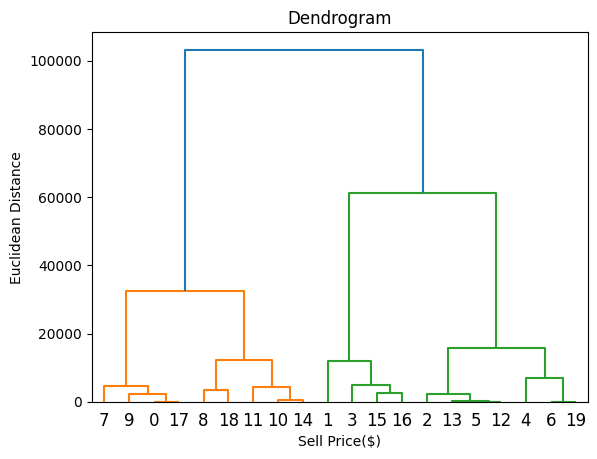

In [40]:
import scipy.cluster.hierarchy as sch
dendrogram=sch.dendrogram(sch.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Sell Price($)')
plt.ylabel('Euclidean Distance')
plt.show()

In [41]:
from sklearn.cluster import AgglomerativeClustering
model = AgglomerativeClustering(n_clusters=2, linkage='ward')
label = model.fit_predict(X_scaled)
print(label)

[0 1 0 1 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0]


In [42]:
df["Cluster"] = label
print(df[["Sell Price($)", "Cluster"]].head())

   Sell Price($)  Cluster
0          18000        0
1          34000        1
2          26100        0
3          40000        1
4          31500        0
